<a href="https://colab.research.google.com/github/MarceloRRodrigues/Deep-Learning_Trabalho-final/blob/main/notebooks/Previs%C3%A3o_demanda_energia_el%C3%A9trica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
#Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Explicar a escolha das bibliotecas


['README.md', 'PJME_hourly.csv', '.git']


O arquivo do Kaggle (https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption) com os dados de Consumo de Energia possuem diversas variações do dataset. O grupo escolheu a variação "PMJE", dados da região Leste dos estados Unidos, conforme proposto na atividade.

In [28]:
#leitura do dataset gravada na variável df
df = pd.read_csv("PJME_hourly.csv")

#vislumbre nos primeiros dados do dataset
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [29]:
#vislumbre nos últimos dados do dataset, visualizando o período 2002 a 2018
df.tail()

,Datetime,PJME_MW
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0
145365,2018-01-02 00:00:00,38608.0


In [30]:
#informações sobre o dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


O dataset possui dados de consumo de energia entre as datas de 31/12/2002 a 01/01/2018. No total, são 145366 dados de consumo, cada um com 2 colunas, "Datetime" (Data e Hora) e "PMJE_MW" (Consumo em MegaWatts).


In [31]:
#Análise do Dataset
print("Quantidade de registros:", len(df))

print("\nValores nulos:")
print(df.isnull().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

#Estatísticas dos dados de consumo energético
print("\nEstatísticas:")
print(df.describe())

Quantidade de registros: 145366

Valores nulos:
Datetime    0
PJME_MW     0
dtype: int64

Duplicados:
0

Estatísticas:
             PJME_MW
count  145366.000000
mean    32080.222831
std      6464.012166
min     14544.000000
25%     27573.000000
50%     31421.000000
75%     35650.000000
max     62009.000000


Alguns dados importantes ->

Consumo Máximo: 62009.00 MW

Consumo Mínimo: 14544.00 MW

Consumo Médio: 32080.22 MW

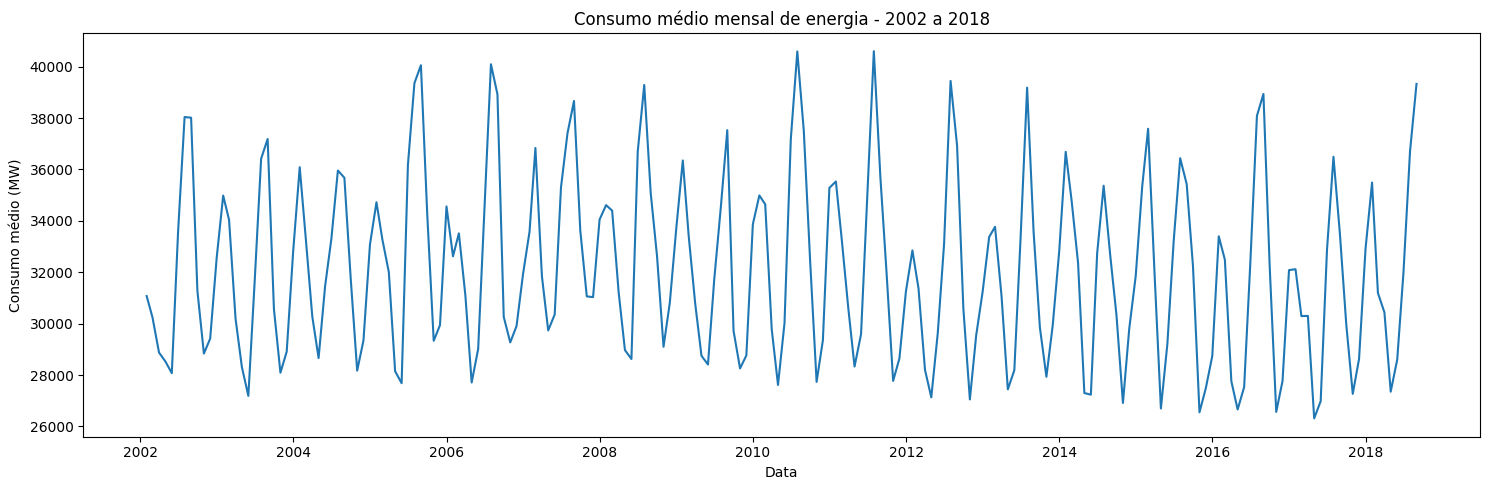

In [33]:
df["Datetime"] = pd.to_datetime(df["Datetime"]) #garante que a coluna Datetime esteja em formato data/hora

#aqui, vamos plotar o consumo médio mensal durante o período de 2002 a 2018, visto que
#plotar um gráfico com todos os 145366 dados tomaria muito tempo e processamento.

df_mensal = (
    df.set_index("Datetime")["PJME_MW"]
      .resample("ME")
      .mean()
)

'''
.set_index("Datetime") -> Define a coluna de datetime como o índice da tabela
["PJME_MW"] -> filtra apenas a coluna de consumo
.resample("ME") -> Agrupa os dados do index pelo último dia de cada mês (ME = Month End)
.mean() -> Calcula a média dos dados agrupados
'''

plt.figure(figsize=(15, 5))

plt.plot(df_mensal.index, df_mensal.values)

plt.title("Consumo médio mensal de energia - 2002 a 2018")
plt.xlabel("Data")
plt.ylabel("Consumo médio (MW)")
plt.tight_layout()

plt.show()

O gráfico apresenta o comportamento do consumo ao longo do tempo.

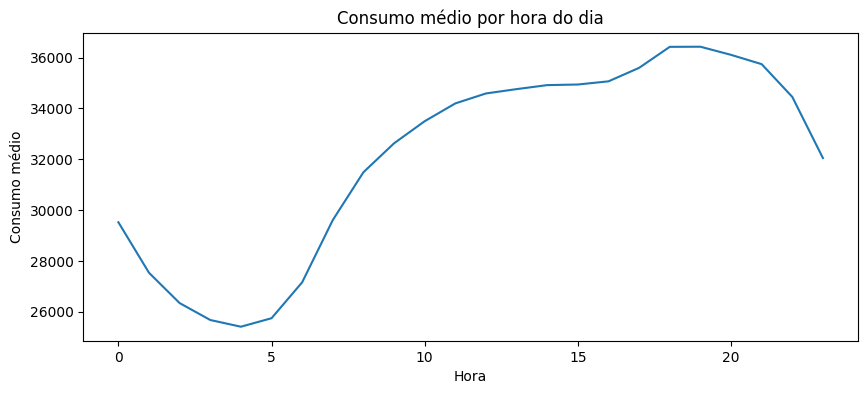

In [35]:
df["hora"] = df["Datetime"].dt.hour

media_por_hora = df.groupby("hora")["PJME_MW"].mean()

media_por_hora.plot(figsize=(10, 4))
plt.title("Consumo médio por hora do dia")
plt.xlabel("Hora")
plt.ylabel("Consumo médio")
plt.show()

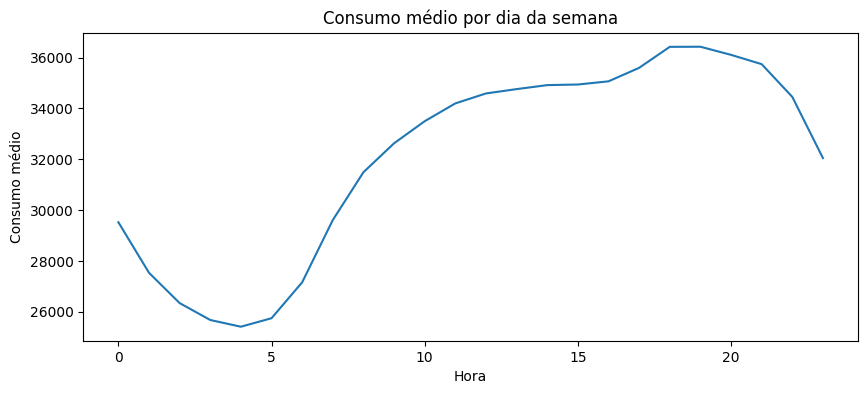

In [36]:
df["dia"] = df["Datetime"].dt.day

media_por_dia = df.groupby("dia")["PJME_MW"].mean()

media_por_hora.plot(figsize=(10, 4))
plt.title("Consumo médio por dia da semana")
plt.xlabel("Hora")
plt.ylabel("Consumo médio")
plt.show()

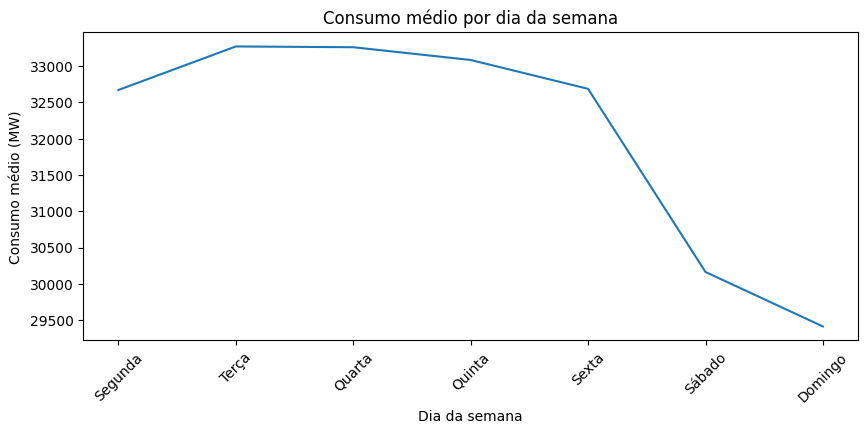

In [37]:
# Cria uma coluna com o dia da semana
df["dia_semana"] = df["Datetime"].dt.dayofweek

# Calcula o consumo médio para cada dia da semana
media_por_dia = df.groupby("dia_semana")["PJME_MW"].mean()

# Renomeia os dias para facilitar a leitura
media_por_dia.index = [
    "Segunda",
    "Terça",
    "Quarta",
    "Quinta",
    "Sexta",
    "Sábado",
    "Domingo"
]

# Gráfico
media_por_dia.plot(figsize=(10, 4))

plt.title("Consumo médio por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Consumo médio (MW)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#treinar e testar modelo de acordo com os dados de saída e entrada definidos. Verificar se uma semana é suficiente para treinar o modelo e prever a temperatura em 1 dia seguinte.